In [6]:
#DL Prac 1      Linear regression by using Deep Neural network: Implement Boston housing price prediction 
# problem by Linear regression using Deep Neural network. Use Boston House price prediction dataset. 

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
data = pd.read_csv('HousingData.csv')
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [11]:
data.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [12]:
data = data.dropna()

<Axes: >

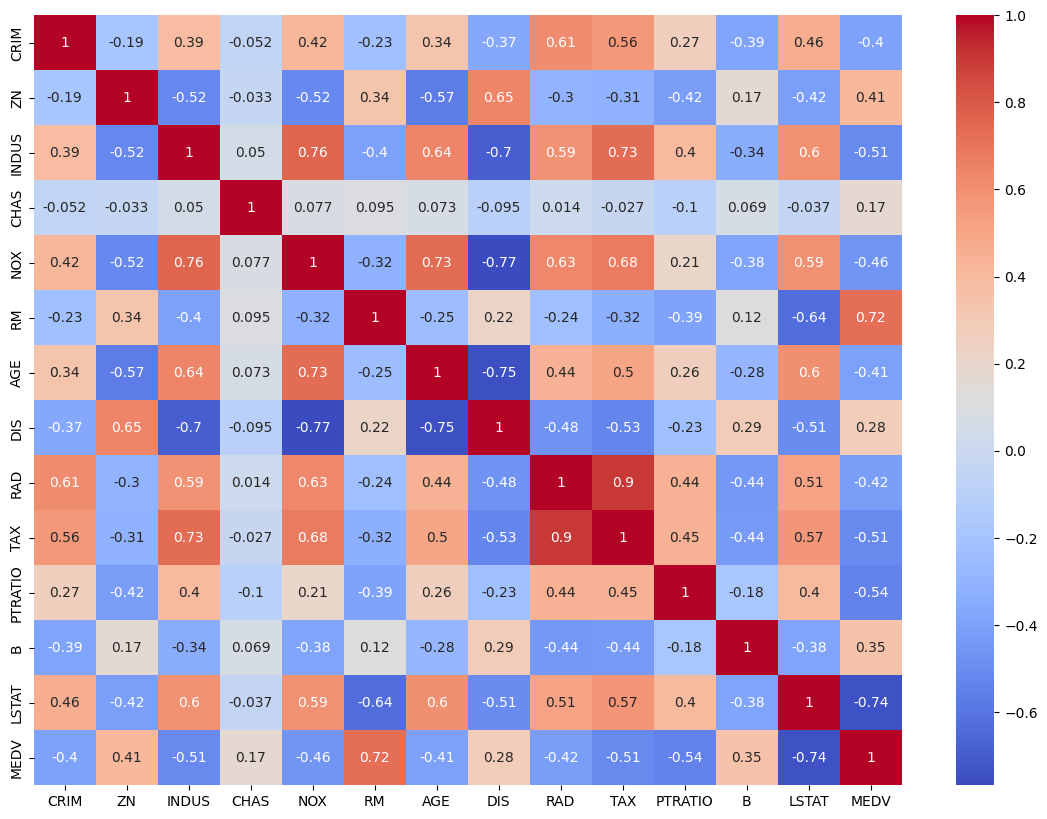

In [14]:
plt.figure(figsize=(14, 10))
sns.heatmap(data.corr(), cmap='coolwarm', annot=True)

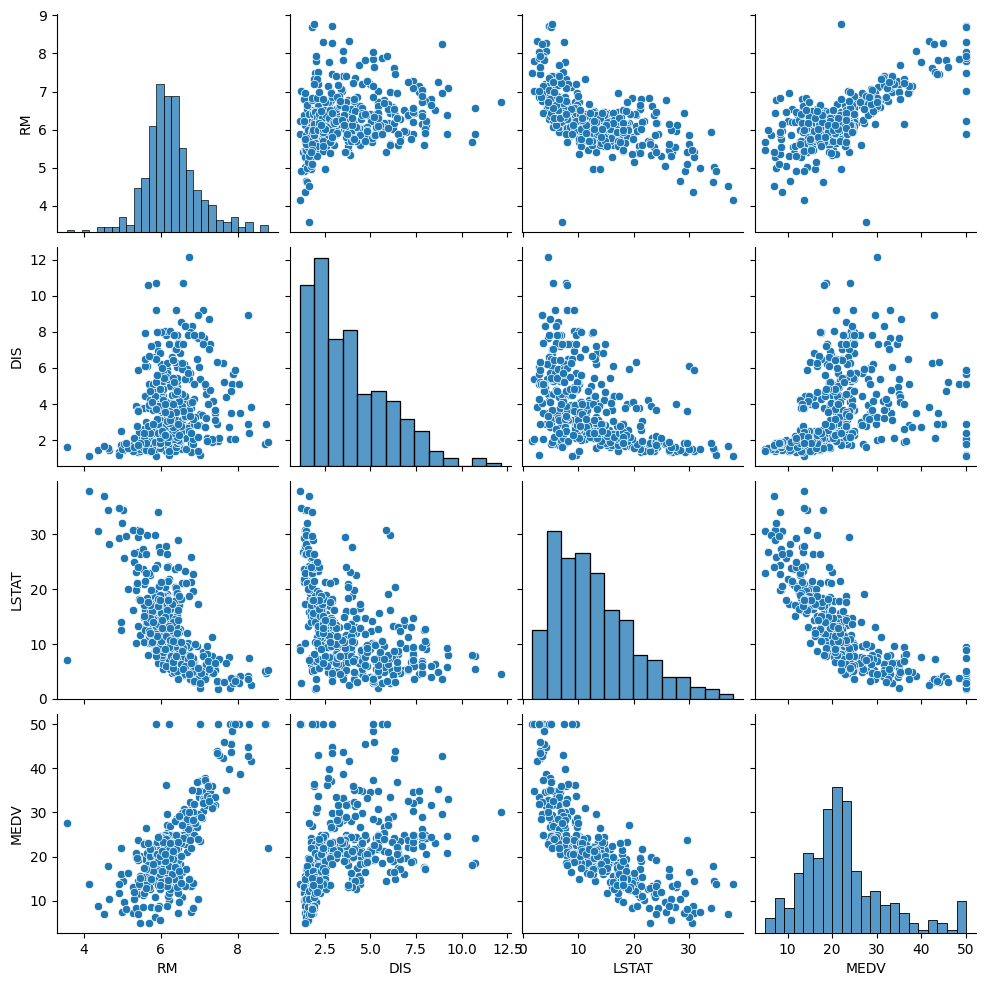

In [15]:
sns.pairplot(data[['RM', 'DIS', 'LSTAT', 'MEDV']])

In [16]:
X = data[['RM', 'DIS', 'LSTAT']]
y = data['MEDV']

In [17]:
train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2)

In [18]:
scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)

In [24]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(3,)))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='linear'))

In [25]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0.001, patience=3, restore_best_weights=True)

In [26]:
model.compile(optimizer='adam', loss='mse', metrics=['mse'])
model.fit(train_x_scaled, train_y, validation_data=(test_x_scaled, test_y), epochs=100, callbacks=[early_stopping])

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 571.0586 - mse: 571.0586 - val_loss: 558.3286 - val_mse: 558.3286
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 546.8753 - mse: 546.8753 - val_loss: 520.0018 - val_mse: 520.0018
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 496.8838 - mse: 496.8838 - val_loss: 446.4889 - val_mse: 446.4889
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 411.2579 - mse: 411.2579 - val_loss: 333.4101 - val_mse: 333.4101
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 291.2638 - mse: 291.2638 - val_loss: 202.3827 - val_mse: 202.3827
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 159.8997 - mse: 159.8997 - val_loss: 106.5016 - val_mse: 106.5016
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 76.0968 - mse: 76.0968 - val_loss: 87.1380 - val_mse: 87.1380
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 55.6012 - mse: 55.6012 - val_loss: 77.7734 - val_mse: 77.7734


In [27]:
model.evaluate(test_x_scaled, test_y)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 30.8038 - mse: 30.8038


[30.80377960205078, 30.80377960205078]